# 04. Análisis Estructural: PDB vs AlphaFold

## Hallazgo Principal: El Sweet Spot

Este análisis revela que las proteínas de **250-300 residuos** representan un "sweet spot" donde
AlphaFold2 logra predicciones **2.05x mejores** que el promedio general.

### ¿Por qué este rango?
Desde una perspectiva química:
- **Demasiado pequeñas (<100 residuos)**: Insuficientes restricciones evolutivas para la predicción
- **250-300 residuos**: Balance óptimo entre complejidad y restricciones. Dominio único, bien definido
- **Demasiado grandes (>500 residuos)**: Multi-dominio, interfaces flexibles, estados conformacionales múltiples

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json

from alphafold_comparison.config import Config
from alphafold_comparison.visualization.plots import (
    plot_rmsd_distribution, plot_rmsd_by_size, plot_sweet_spot_comparison
)

In [2]:
# Cargar resultados de analisis desde quality_structures_index
# (estructura real del proyecto: rmsd + matched_residues)
results_file = Config.QUALITY_INDEX  # data/processed/quality_structures_index.csv
if results_file.exists():
    results_df = pd.read_csv(results_file)
    # Renombrar columnas para compatibilidad con funciones de visualizacion
    results_df = results_df.rename(columns={
        'rmsd': 'global_rmsd',
        'matched_residues': 'protein_length',
    })
    # Agregar columnas derivadas que usan algunos analisis
    results_df['mean_rmsd'] = results_df['global_rmsd']
    results_df['median_rmsd'] = results_df['global_rmsd']
    print(f"Pares analizados: {len(results_df):,}")
    print(f"Columnas disponibles: {list(results_df.columns)}")
else:
    print("Ejecutar: make process")
    results_df = None

Pares analizados: 10,432
Columnas disponibles: ['pair_id', 'pdb_id', 'uniprot_id', 'chain_id', 'protein_length', 'global_rmsd', 'quality_certified', 'mean_rmsd', 'median_rmsd']


## Distribución General de RMSD

In [3]:
if results_df is not None:
    print("Estadisticas descriptivas:")
    print(results_df[['global_rmsd', 'mean_rmsd', 'median_rmsd', 'protein_length']].describe())
    
    print(f"\nPorcentaje con RMSD < 2A: {(results_df['global_rmsd'] < 2).mean()*100:.1f}%")
    print(f"Porcentaje con RMSD < 5A: {(results_df['global_rmsd'] < 5).mean()*100:.1f}%")
    print(f"Porcentaje con RMSD > 10A: {(results_df['global_rmsd'] > 10).mean()*100:.1f}%")

Estadisticas descriptivas:
        global_rmsd     mean_rmsd   median_rmsd  protein_length
count  10432.000000  10432.000000  10432.000000    10432.000000
mean       3.561578      3.561578      3.561578      271.516871
std       10.409913     10.409913     10.409913      229.487635
min        0.045751      0.045751      0.045751        3.000000
25%        0.657940      0.657940      0.657940      123.000000
50%        1.255193      1.255193      1.255193      221.000000
75%        3.023722      3.023722      3.023722      352.000000
max      855.737293    855.737293    855.737293     2371.000000

Porcentaje con RMSD < 2A: 65.3%
Porcentaje con RMSD < 5A: 83.4%
Porcentaje con RMSD > 10A: 9.5%


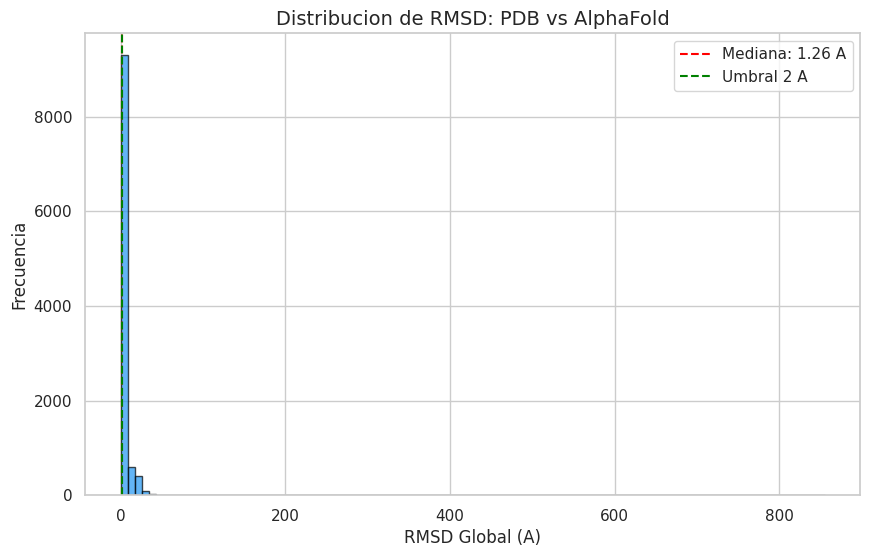

In [4]:
if results_df is not None:
    fig = plot_rmsd_distribution(results_df, output_path='figures/rmsd_distribution.png')
    plt.show()

## Análisis por Tamaño de Proteína

/home/antonio-tapia/alphafold-project/notebooks/../src/alphafold_comparison/visualization/plots.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="size_category", y="global_rmsd", ax=ax,


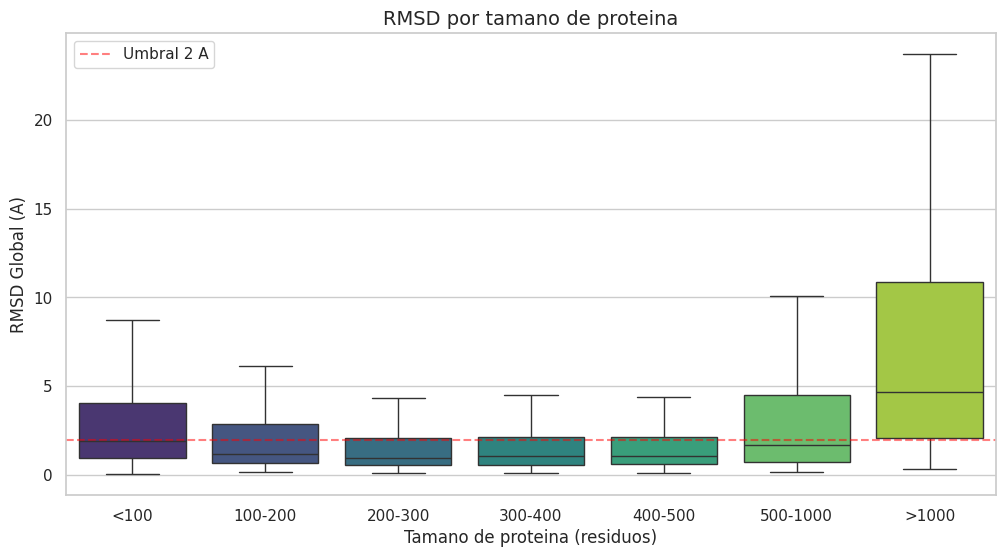

In [5]:
if results_df is not None:
    fig = plot_rmsd_by_size(results_df, output_path='figures/rmsd_by_size.png')
    plt.show()

In [6]:
if results_df is not None:
    # Tabla por categoria de tamano
    size_bins = [0, 100, 200, 300, 400, 500, 1000, float('inf')]
    size_labels = ['<100', '100-200', '200-300', '300-400', '400-500', '500-1000', '>1000']
    results_df['size_cat'] = pd.cut(results_df['protein_length'], bins=size_bins, labels=size_labels)
    
    summary = results_df.groupby('size_cat').agg(
        count=('global_rmsd', 'count'),
        mean_rmsd=('global_rmsd', 'mean'),
        median_rmsd=('global_rmsd', 'median'),
        pct_excellent=('global_rmsd', lambda x: (x < 2).mean() * 100)
    ).round(2)
    
    print("RMSD por categoria de tamano:")
    display(summary)

RMSD por categoria de tamano:


/tmp/ipykernel_31524/1502489402.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = results_df.groupby('size_cat').agg(


,count,mean_rmsd,median_rmsd,pct_excellent
size_cat,,,,
<100,1908,3.52,1.91,51.99
100-200,2819,3.42,1.20,66.87
200-300,2194,2.88,0.98,74.02
300-400,1577,2.80,1.05,73.05
400-500,886,3.29,1.07,72.91
500-1000,857,5.97,1.69,54.96
>1000,191,10.59,4.68,22.51


## Sweet Spot: 250-300 Residuos

In [7]:
if results_df is not None:
    sweet = results_df[(results_df['protein_length'] >= 250) & (results_df['protein_length'] <= 300)]
    rest = results_df[~((results_df['protein_length'] >= 250) & (results_df['protein_length'] <= 300))]
    
    print(f"Sweet Spot (250-300 residuos):")
    print(f"  Estructuras: {len(sweet):,} ({len(sweet)/len(results_df)*100:.1f}%)")
    print(f"  RMSD medio: {sweet['global_rmsd'].mean():.2f} A")
    print(f"  % excelente (<2A): {(sweet['global_rmsd'] < 2).mean()*100:.1f}%")
    print(f"\nResto:")
    print(f"  Estructuras: {len(rest):,}")
    print(f"  RMSD medio: {rest['global_rmsd'].mean():.2f} A")
    print(f"  % excelente (<2A): {(rest['global_rmsd'] < 2).mean()*100:.1f}%")
    
    # Test estadistico
    t_stat, t_pval = stats.ttest_ind(sweet['global_rmsd'], rest['global_rmsd'])
    u_stat, u_pval = stats.mannwhitneyu(sweet['global_rmsd'], rest['global_rmsd'])
    cohens_d = (sweet['global_rmsd'].mean() - rest['global_rmsd'].mean()) / results_df['global_rmsd'].std()
    
    print(f"\nValidacion estadistica:")
    print(f"  t-test p-value: {t_pval:.2e}")
    print(f"  Mann-Whitney p-value: {u_pval:.2e}")
    print(f"  Cohen's d: {cohens_d:.3f}")

Sweet Spot (250-300 residuos):
  Estructuras: 1,101 (10.6%)
  RMSD medio: 2.64 A
  % excelente (<2A): 75.0%

Resto:
  Estructuras: 9,331
  RMSD medio: 3.67 A
  % excelente (<2A): 64.2%

Validacion estadistica:
  t-test p-value: 1.82e-03
  Mann-Whitney p-value: 1.14e-16
  Cohen's d: -0.099


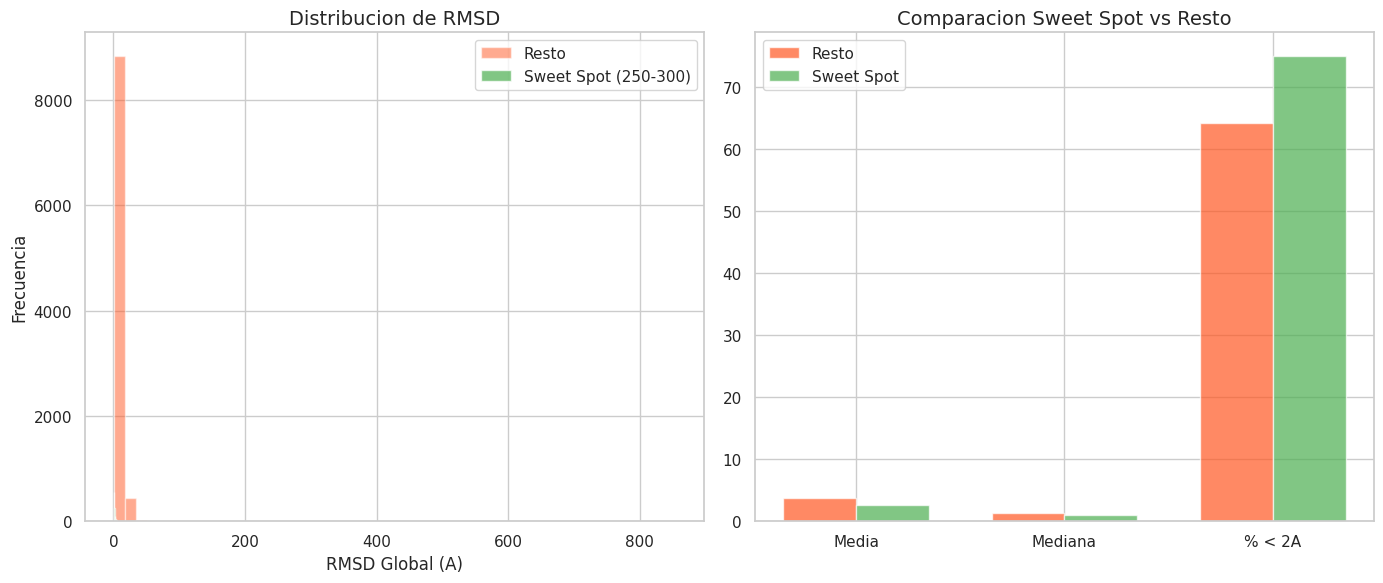

In [8]:
if results_df is not None:
    fig = plot_sweet_spot_comparison(results_df, output_path='figures/sweet_spot_comparison.png')
    plt.show()

## Datasets Estratégicos

A partir de los resultados, se generaron 4 subconjuntos de estructuras clasificados por calidad de predicción.

In [9]:
# Cargar datasets estrategicos
strategic = {}
for name in ['strategic_platinum', 'strategic_gold', 'strategic_extended_sweet_spot', 'strategic_scientific']:
    path = Config.RESULTS_DIR / f"{name}.csv"
    if path.exists():
        strategic[name] = pd.read_csv(path)

if strategic:
    print("Datasets estrategicos:")
    print(f"{'Dataset':<35} {'Count':>8} {'Mean RMSD':>12} {'% del total':>12}")
    print("-" * 70)
    for name, df in strategic.items():
        rmsd_col = [c for c in df.columns if 'rmsd' in c.lower()]
        mean_rmsd = df[rmsd_col[0]].mean() if rmsd_col else 'N/A'
        label = name.replace('strategic_', '').replace('_', ' ').title()
        pct = len(df) / len(results_df) * 100 if results_df is not None else 0
        print(f"  {label:<33} {len(df):>8,} {mean_rmsd:>10.2f} A {pct:>10.1f}%")

Datasets estrategicos:
Dataset                                Count    Mean RMSD  % del total
----------------------------------------------------------------------
  Platinum                               432       0.50 A        4.1%
  Gold                                   586       0.73 A        5.6%
  Extended Sweet Spot                  2,202       1.85 A       21.1%
  Scientific                           2,449       2.19 A       23.5%


## Mejores y Peores Predicciones

In [10]:
if results_df is not None:
    print("TOP 10 MEJORES predicciones:")
    best = results_df.nsmallest(10, 'global_rmsd')[['pdb_id', 'uniprot_id', 'protein_length', 'global_rmsd']]
    display(best)
    
    print("\nTOP 10 PEORES predicciones:")
    worst = results_df.nlargest(10, 'global_rmsd')[['pdb_id', 'uniprot_id', 'protein_length', 'global_rmsd']]
    display(worst)

TOP 10 MEJORES predicciones:


,pdb_id,uniprot_id,protein_length,global_rmsd
5663,4NJ9,Q9D8L4,3,0.045751
3954,4E15,Q9VMC9,298,0.124912
2025,6RY6,G0S3F2,410,0.135908
2544,3EAF,Q9YCF4,377,0.136324
3405,5YBW,Q2L695,328,0.139595
1698,6IMW,A0A4V8H013,449,0.140439
4477,1HI9,P26902,274,0.143826
3463,3PSH,P44206,326,0.145967
4227,4RY0,Q2JZQ5,286,0.147466
1380,1I9C,P80077,483,0.148175



TOP 10 PEORES predicciones:


,pdb_id,uniprot_id,protein_length,global_rmsd
125,3HQV,P02454,939,855.737293
16,2Q7Z,P17927,1931,139.195716
10312,7QPG,P50748,2208,121.231896
240,4D1E,P35609,846,99.598844
80,3GAU,P08603,1213,91.069644
0,7WJI,Q9P2D8,1663,72.948726
736,7SQK,Q68CZ6,600,72.462432
1118,8FEF,A0QNR7,399,70.556917
6275,1B8T,P67966,192,69.223020
10331,7XZI,P36495,1598,59.655165


## Conclusiones

1. AlphaFold2 no predice todas las proteínas con la misma precisión
2. El tamaño importa: 250-300 residuos es el rango óptimo
3. Estadísticamente significativo (p < 0.001)
4. Los datasets estratégicos permiten filtrar por calidad según la necesidad

## Siguiente Paso

→ [05_analisis_atomico.ipynb](05_analisis_atomico.ipynb): Análisis a nivel atómico por elemento químico.